# Chronos-2 Fine-tuning (LoRA)


## Import libraries


In [1]:
import pandas as pd

from timecopilot import TimeCopilotForecaster


## Load the dataset

The DataFrame must include: unique_id, ds, y. We use the same dataset as the Chronos family notebook.


In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data


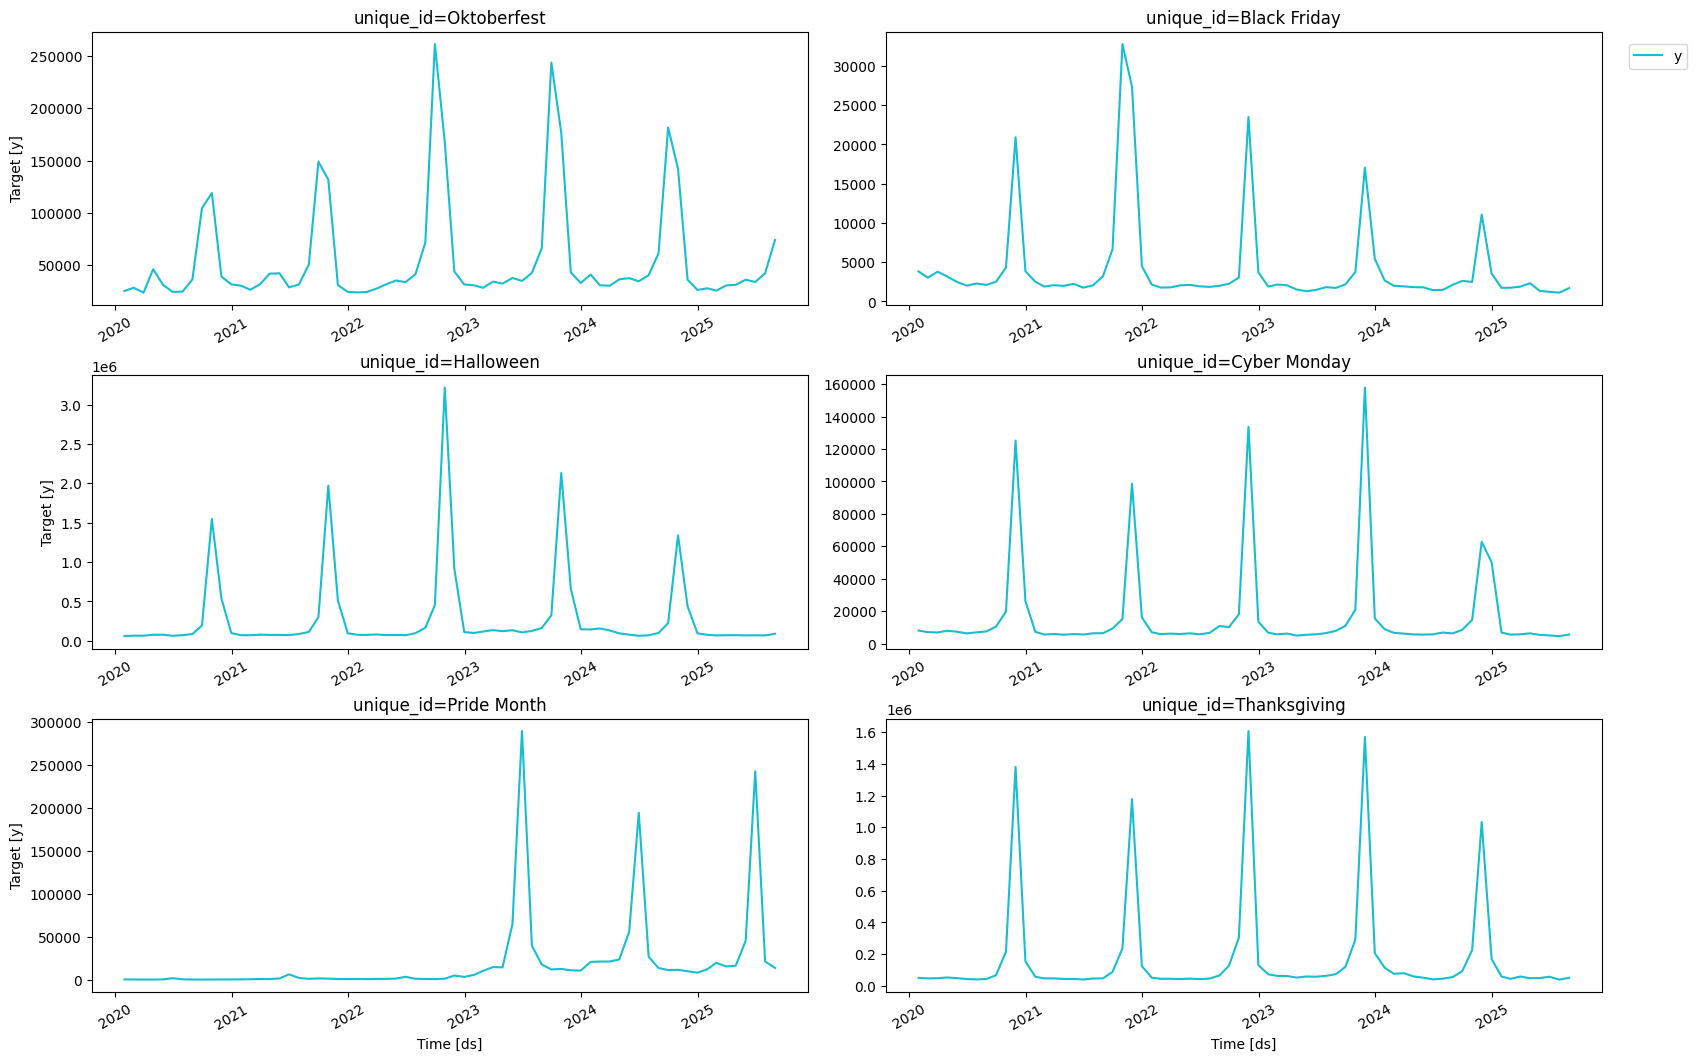

In [3]:
TimeCopilotForecaster.plot(df)


## Fine-tuning config


In [4]:
QUICK_RUN = True  # Set to False for full run
num_steps = 50 if QUICK_RUN else 300
prediction_length = 12
output_dir = "chronos-2-finetuned/events_pageviews_lora"


## Prepare data for Chronos-2

Convert the DataFrame (unique_id, ds, y) into the format required by Chronos2Pipeline.fit: a list of dicts with `{"target": np.ndarray}` per series.


In [5]:
import numpy as np
from pathlib import Path

train_df = df.query("ds <= '2024-08-31'")


def df_to_chronos2_inputs(data: pd.DataFrame):
    """Convert DataFrame (unique_id, ds, y) to list of dicts for Chronos2Pipeline.fit."""
    out = []
    for _, g in data.groupby("unique_id", sort=False):
        y = g.sort_values("ds")["y"].to_numpy(dtype=np.float32)
        out.append({"target": y})
    return out


train_inputs = df_to_chronos2_inputs(train_df)
print(f"Number of series: {len(train_inputs)}")


Number of series: 6


## Fine-tune Chronos-2 (LoRA)


In [6]:
from timecopilot.models.foundation.chronos import ChronosFinetuner

finetuner = ChronosFinetuner("amazon/chronos-2")
Path(output_dir).mkdir(parents=True, exist_ok=True)

finetuned_pipe = finetuner.finetune_chronos2(
    inputs=train_inputs,
    prediction_length=prediction_length,
    finetune_mode="lora",
    lora_config={
        "r": 8,
        "lora_alpha": 16,
        "target_modules": ["self_attention.q", "self_attention.v"],
    },
    num_steps=num_steps,
    learning_rate=1e-5,
    batch_size=32,
    output_dir=output_dir,
)


 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss


## Forecast and plot

Run cross-validation and plot train context + forecast horizon using the same style as the Chronos family notebook.


In [8]:
from timecopilot.models.foundation.chronos import Chronos
from timecopilot.models.stats import SeasonalNaive

chronos_models = [Chronos(repo_id="amazon/chronos-2", alias="amazon/chronos-2")]
# Chronos saves the loadable checkpoint in output_dir/finetuned-ckpt
finetuned_ckpt = str(Path(output_dir) / "finetuned-ckpt")
chronos_models.append(Chronos(repo_id=finetuned_ckpt, alias="chronos-2-finetuned"))
models = chronos_models + [SeasonalNaive()]
tcf = TimeCopilotForecaster(models=models)

level = [20, 40, 60, 80]
cv_df = tcf.cross_validation(df=df, h=prediction_length, level=level)


100%|██████████| 1/1 [00:00<00:00,  3.98it/s]
1it [00:01,  1.39s/it]
100%|██████████| 1/1 [00:00<00:00,  3.85it/s]
1it [00:00,  2.65it/s]
1it [00:02,  2.94s/it]


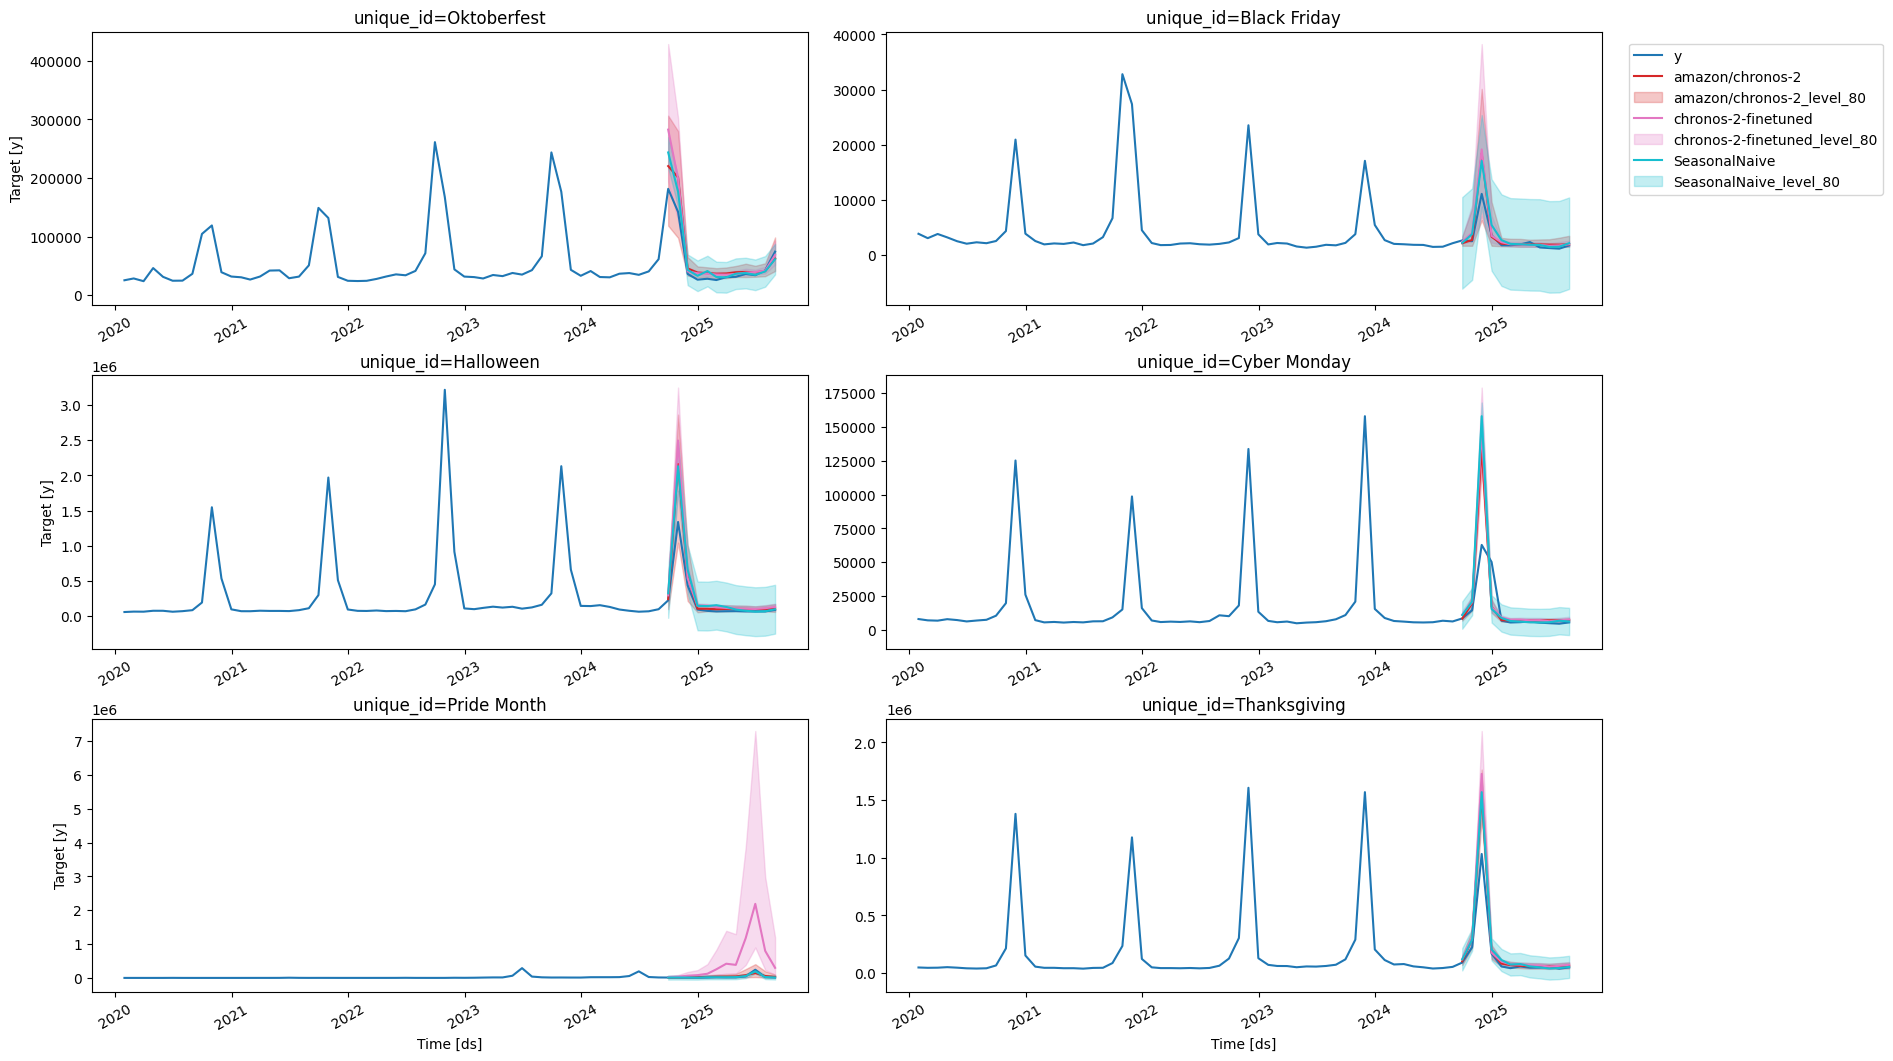

In [9]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


In [10]:
cv_df.head()


,unique_id,ds,cutoff,y,amazon/chronos-2,amazon/chronos-2-lo-20,amazon/chronos-2-hi-20,amazon/chronos-2-lo-40,amazon/chronos-2-hi-40,amazon/chronos-2-lo-60,...,chronos-2-finetuned-hi-80,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,2095.000977,1996.536621,2180.335938,1889.296875,2296.194336,1789.088623,...,3257.748047,2160.0,518.105774,-1238.539673,-3294.386475,-6145.491211,3801.894287,5558.539551,7614.386719,10465.491211
1,Black Friday,2024-10-31,2024-08-31,2470,2686.513184,2313.483154,3336.228516,2049.763428,4364.782715,1866.728760,...,9037.542969,3746.0,2104.105713,347.460358,-1708.386597,-4559.491211,5387.894043,7144.539551,9200.386719,12051.491211
2,Black Friday,2024-11-30,2024-08-31,11058,18391.699219,15877.386719,20407.904297,12313.873047,22807.003906,9150.784180,...,38244.417969,17053.0,15411.105469,13654.459961,11598.613281,8747.508789,18694.894531,20451.539062,22507.386719,25358.490234
3,Black Friday,2024-12-31,2024-08-31,3548,3263.995117,2747.131836,4157.945312,2353.218262,5379.587402,1998.092285,...,7093.774414,5407.0,3765.105713,2008.460327,-47.386593,-2898.491211,7048.894043,8805.540039,10861.386719,13712.491211
4,Black Friday,2025-01-31,2024-08-31,1724,1994.929932,1902.393799,2072.615967,1800.035645,2184.014648,1696.258057,...,2732.351074,2656.0,1014.105774,-742.539673,-2798.386475,-5649.491211,4297.894043,6054.539551,8110.386719,10961.491211


## Evaluation


In [11]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps


In [12]:

eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(by="scaled_crps").round(3)


metric,mase,scaled_crps
amazon/chronos-2,1.627,0.359
SeasonalNaive,1.576,0.521
chronos-2-finetuned,6.644,2.149
